## 1. What this notebook computes

The length of a vector is the square root of a sum of squares. Paul Dirac found in
1928 that such a square root can be written as a *linear* expression, provided the
coefficients are matrices that anticommute. This is the reason why gamma matrices
exist, and why the field of this book has 16 components. This notebook

- shows that ordinary numbers cannot do it;
- checks exactly (with sympy, for all values of the variables) the square roots of
  $p^2 + q^2$ and of $p^2 - q^2$ made from real $2 \times 2$ matrices, the three
  Pauli matrices (three directions), and Dirac's $4 \times 4$ matrices (time and
  three space directions);
- checks exactly that the author's eight $16 \times 16$ gammas give the square root
  of the quadratic form of his 4+4 dimensional space-time:
  $(\sum_a p_a\gamma^{(x_a)})^2 = (p_1^2 + p_2^2 + p_3^2 - p_4^2 - p_5^2 - p_6^2
  - p_7^2 + p_8^2)\, I_{16}$;
- derives, line by line, what the first-order field equation
  $\sum_a \gamma^{(x_a)} \partial_a \Psi = m\Psi$ says about plane waves in flat
  4+4 dimensions: $E^2 = m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2$,
  and reproduces the Revision record of this relation and of its exact example;
- draws six figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 04b (Square roots of quadratic forms: from Pauli and Dirac to the author's
gammas) is the file `Revision/textbook/notebooks/04b_square_roots.ipynb` of the
repository Dirac_claude. It shows why the gamma matrices exist: a sum of squares with
plus and minus signs has a linear square root only when the coefficients are
anticommuting matrices. It checks this exactly for two 2 by 2 examples, the Pauli
matrices, Dirac's 4 by 4 matrices and the author's eight 16 by 16 gammas, derives the
plane-wave relation of the first-order equation in flat 4+4 dimensions and reproduces the
Revision record of this relation, and draws six figures. It needs a computer with Windows
11, macOS or Linux, an internet connection for the installation, the program Git, and
Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 04b_square_roots.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 04b_square_roots.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
04b_square_roots.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/04b.captions.json`,
`Revision/textbook/figures/04b_1_square_roots_2x2.png`,
`Revision/textbook/figures/04b_2_pauli_dirac_tables.png`,
`Revision/textbook/figures/04b_3_dirac_mass_shell.png`,
`Revision/textbook/figures/04b_4_square_root_8d.png`,
`Revision/textbook/figures/04b_5_mass_shell_4p4.png` and
`Revision/textbook/figures/04b_6_extra_time_momentum.png`. It changes no other file of
the repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files exist
    ALL 16 CHECKS PASSED (notebook 04b)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/04b_square_roots.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for `Revision/algebra/gammas.json` or
  `Revision/theory/reports/python-field-theory.json`: the notebook reads these Revision
  record files of the repository; they are part of every complete clone. Run `git status`
  in the repository folder: if it reports them as deleted, restore them with the command
  below and run the notebook again.

      git checkout HEAD Revision/algebra Revision/theory

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 04b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 04b (Square roots of quadratic forms: from Pauli and Dirac to the author's
# gammas) is the file Revision/textbook/notebooks/04b_square_roots.ipynb of the
# repository Dirac_claude. It shows why the gamma matrices exist: a sum of squares with
# plus and minus signs has a linear square root only when the coefficients are
# anticommuting matrices. It checks this exactly for two 2 by 2 examples, the Pauli
# matrices, Dirac's 4 by 4 matrices and the author's eight 16 by 16 gammas, derives the
# plane-wave relation of the first-order equation in flat 4+4 dimensions and reproduces
# the Revision record of this relation, and draws six figures. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 04b_square_roots.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 04b_square_roots.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 04b_square_roots.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/04b.captions.json,
# Revision/textbook/figures/04b_1_square_roots_2x2.png,
# Revision/textbook/figures/04b_2_pauli_dirac_tables.png,
# Revision/textbook/figures/04b_3_dirac_mass_shell.png,
# Revision/textbook/figures/04b_4_square_root_8d.png,
# Revision/textbook/figures/04b_5_mass_shell_4p4.png and
# Revision/textbook/figures/04b_6_extra_time_momentum.png. It changes no other file of
# the repository; running it headless or saving it in JupyterLab also rewrites the
# notebook file itself. It does not use the internet while it runs. The files it writes
# are the same files that are stored in the repository (on another computer a figure may
# differ in a few bytes, which is harmless). To get the stored versions back, run this
# command in the repository folder (it also undoes every change you made yourself in the
# folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files exist
#     ALL 16 CHECKS PASSED (notebook 04b)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/04b_square_roots.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for Revision/algebra/gammas.json or
#   Revision/theory/reports/python-field-theory.json: the notebook reads these Revision
#   record files of the repository; they are part of every complete clone. Run git status
#   in the repository folder: if it reports them as deleted, restore them with the
#   command below and run the notebook again.
#     git checkout HEAD Revision/algebra Revision/theory
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "04b"  # this notebook: chapter 04, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 04b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Quadratic form**: a sum of squares of variables, each with a plus or a minus
  sign, such as $p^2 + q^2$ (Pythagoras) or $p^2 - q^2$.
- **Square root of a quadratic form**: an expression $L$, linear in the variables,
  whose square is the quadratic form: $L^2 = p^2 + q^2$ (times the identity matrix
  when $L$ is a matrix).
- **Complex number**: $x + iy$ with real $x, y$ and $i^2 = -1$. A matrix may have
  complex entries.
- **Conjugate transpose** $M^\dagger$: transpose $M$ and replace every entry
  $x + iy$ by $x - iy$. A matrix is **Hermitian** if $M^\dagger = M$.
- **Anticommute**: $AB = -BA$, that is $\{A, B\} = AB + BA = 0$.
- **Clifford relation**: $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab} I$, with
  $\eta$ a diagonal matrix of signs $\pm 1$ (the *metric* of the directions).
- **Eigenvalue and eigenvector**: a number $\lambda$ and a nonzero column $u$ with
  $M u = \lambda u$.
- **Smallest singular value** of a square matrix $M$: the smallest length of $Mu$
  over all columns $u$ of length 1. It is 0 exactly when some nonzero $u$ has
  $Mu = 0$. numpy computes it with `np.linalg.svd`.
- **Plane wave**: a solution of the form $u\, e^{i(k \cdot x - E x_4)}$, with a
  constant column $u$; $E$ is its *energy* (frequency in the time $x_4$) and the
  $k_a$ are its *momenta* (wave numbers in the other directions).
- **Mass shell** (or *dispersion relation*): the relation between $E$, the $k_a$
  and the mass $m$ that a plane wave must obey.
- **Flat 4+4 space**: space-time with the constant metric
  $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ in the order
  $x_1, \dots, x_8$: no gravity, no inflation, no deflation.
- **sympy, symbol**: sympy computes with letters (symbols) such as $p$ and $q$ that
  stand for any number; an identity that sympy proves holds for every value.
- **Floating-point number**: a number stored with about 16 significant digits;
  numpy computes with them, so its results may differ from the exact ones in the
  last digits (rounding). **Random numbers with a seed**: numbers that look random
  but are the same in every run, because the generator starts from a fixed number.

## 4. The physical and mathematical situation

**The square-root problem.** Can $\sqrt{p^2 + q^2}$ be written as
$\alpha p + \beta q$? Squaring,
$(\alpha p + \beta q)^2 = \alpha^2 p^2 + (\alpha\beta + \beta\alpha) pq + \beta^2 q^2$
(multiply out; $\alpha\beta$ and $\beta\alpha$ are kept apart because for matrices
the order matters). This equals $p^2 + q^2$ for all $p, q$ exactly when
$\alpha^2 = 1$, $\beta^2 = 1$ and $\alpha\beta + \beta\alpha = 0$. For numbers,
$\alpha\beta + \beta\alpha = 2\alpha\beta = 0$ forces $\alpha = 0$ or $\beta = 0$,
which contradicts $\alpha^2 = \beta^2 = 1$. For matrices it is possible.

**The general rule.** For $n$ directions with signs $\eta^{aa} = \pm 1$ we want
$(\sum_a p_a \gamma^a)^2 = (\sum_a \eta^{aa} p_a^2) I$ for all numbers $p_a$.
Multiplying out, $(\sum_a p_a\gamma^a)^2 = \sum_{a,b} p_a p_b \gamma^a\gamma^b$; the
terms $(a, b)$ and $(b, a)$ have the same factor $p_a p_b$, so the sum equals
$\tfrac12 \sum_{a,b} p_a p_b (\gamma^a\gamma^b + \gamma^b\gamma^a)$. This is
$\sum_a \eta^{aa} p_a^2 I$ for all $p$ exactly when the Clifford relation
$\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab} I$ holds.

**Why physics needs it.** In special relativity a particle of mass $m$, energy $E$
and momentum $k$ obeys $E^2 = m^2 + k_1^2 + k_2^2 + k_3^2$. Dirac wanted a
first-order equation (only first derivatives) whose square is this relation; he
needed four anticommuting matrices, one with square $+1$ and three with square $-1$
in his sign convention, and found $4 \times 4$ ones.

**The author's 4+4 space-time.** It has eight directions: 3-space $x_1, x_2, x_3$
(space-like), the time $x_4$ and the three extra times $x_5, x_6, x_7$ (time-like;
in the author's metric they deflate exponentially, with the scale factor
$e^{-a_4}\sin^{1/6} z$), and the hidden space direction $x_8$. In a local frame the
signs are $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$, and the author's
eight real $16 \times 16$ matrices satisfy the Clifford relation with this $\eta$.
The field equation of the theory is $\gamma^\mu D_\mu\Psi = (m + U'(S))\Psi$, in which
$\gamma^\mu$ is $\gamma^{(x_\mu)}$ divided by the frame factor
$\sqrt{|g_{\mu\mu}|}$ of the direction $x_\mu$, $D_\mu$ is the derivative along
$x_\mu$ corrected by the gravitational field, and $U'(S)$ comes from the
self-interaction.

**What this notebook does with it.** It studies the equation
$\sum_a \gamma^{(x_a)} \partial_a\Psi = m\Psi$ in **flat** 4+4 space, where the
metric is the constant $\eta$: no gravity, no inflation and no deflation. It is a
model for the algebra only: in the author's space-time the extra times deflate at
every moment, and this notebook does not claim otherwise. What carries over is the
algebra of the frame: in a region so small that the metric functions change little
across it, plane waves with *frame momenta* $k_a$ obey the same matrix algebra (the
Revision record treats this local plane-wave analysis with the coefficients of the
equation held fixed). Nothing in this notebook depends on the curvature.

## 5. Numbers are not enough

The next cell asks sympy for all numbers $\alpha, \beta$ (real or complex) with
$\alpha^2 = 1$, $\beta^2 = 1$ and $\alpha\beta + \beta\alpha = 2\alpha\beta = 0$.
`sp.solve` returns the list of all solutions; it must be empty.

In [2]:
import numpy as np  # floating-point arrays and linear algebra
import sympy as sp  # exact algebra with symbols

alpha, beta = sp.symbols("alpha beta")  # two unknown numbers
equations = [alpha**2 - 1, beta**2 - 1, 2 * alpha * beta]  # each must equal 0
solutions = sp.solve(equations, [alpha, beta], dict=True)  # ** is a power
say(f"number solutions of alpha^2 = 1, beta^2 = 1, 2 alpha beta = 0: {solutions}")
check(solutions == [], "no two numbers solve the square-root problem")

number solutions of alpha^2 = 1, beta^2 = 1, 2 alpha beta = 0: []
PASS no two numbers solve the square-root problem


## 6. Two real $2 \times 2$ matrices

The matrices
$\sigma_x = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ and
$\sigma_z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$ square to $I_2$ and
anticommute. So $(p\sigma_x + q\sigma_z)^2 = (p^2 + q^2) I_2$. A real matrix can also
square to $-I_2$: $N = \begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix}$ has
$N^2 = -I_2$, and it anticommutes with $\sigma_x$; so
$(p\sigma_x + qN)^2 = (p^2 - q^2) I_2$, a square root of a *difference* of squares,
the kind that space and time need. The next cell checks both identities exactly
with the symbols $p$ and $q$, and prints the worked example $p = 3$, $q = 4$:
$3\sigma_x + 4\sigma_z = \begin{pmatrix} 4 & 3 \\ 3 & -4 \end{pmatrix}$, whose square
is $\begin{pmatrix} 16 + 9 & 12 - 12 \\ 12 - 12 & 9 + 16 \end{pmatrix} = 25 I_2$.

In [3]:
sigma_x = sp.Matrix([[0, 1], [1, 0]])
sigma_z = sp.Matrix([[1, 0], [0, -1]])
N = sp.Matrix([[0, 1], [-1, 0]])
I2 = sp.eye(2)  # the 2 x 2 identity matrix
p, q = sp.symbols("p q", real=True)  # two symbols that stand for any real numbers

euclidean = ((p * sigma_x + q * sigma_z) ** 2).expand()  # multiplied out
indefinite = ((p * sigma_x + q * N) ** 2).expand()
say(f"(p sigma_x + q sigma_z)^2 = {euclidean.tolist()}")
say(f"(p sigma_x + q N)^2 = {indefinite.tolist()}")
example = 3 * sigma_x + 4 * sigma_z
say(f"3 sigma_x + 4 sigma_z = {example.tolist()}, its square = "
    f"{(example * example).tolist()}")
check(euclidean == (p**2 + q**2) * I2 and (example * example) == 25 * I2,
      "(p sigma_x + q sigma_z)^2 = (p^2 + q^2) I2 for all p, q")
check(indefinite == (p**2 - q**2) * I2,
      "(p sigma_x + q N)^2 = (p^2 - q^2) I2 for all p, q")

(p sigma_x + q sigma_z)^2 = [[p**2 + q**2, 0], [0, p**2 + q**2]]
(p sigma_x + q N)^2 = [[p**2 - q**2, 0], [0, p**2 - q**2]]
3 sigma_x + 4 sigma_z = [[4, 3], [3, -4]], its square = [[25, 0], [0, 25]]
PASS (p sigma_x + q sigma_z)^2 = (p^2 + q^2) I2 for all p, q
PASS (p sigma_x + q N)^2 = (p^2 - q^2) I2 for all p, q


A square root of a matrix multiple $c I_2$ has the eigenvalues $+\sqrt{c}$ and
$-\sqrt{c}$ (if $Mu = \lambda u$ then $M^2 u = \lambda^2 u = c\, u$, so
$\lambda^2 = c$). For $p^2 - q^2 < 0$ these are imaginary. The next cell computes
the eigenvalues numerically for $q = 1$ and 201 values of $p$ from $-3$ to $3$, checks
them against $\pm\sqrt{p^2 + 1}$ and $\pm\sqrt{p^2 - 1}$, and draws them: on the
left the Euclidean root (always real), on the right the real and imaginary parts of
the eigenvalues of the indefinite root (real for $|p| > 1$, imaginary for
$|p| < 1$).

PASS numpy eigenvalues equal +-sqrt(p^2 + 1), +-sqrt(p^2 - 1)


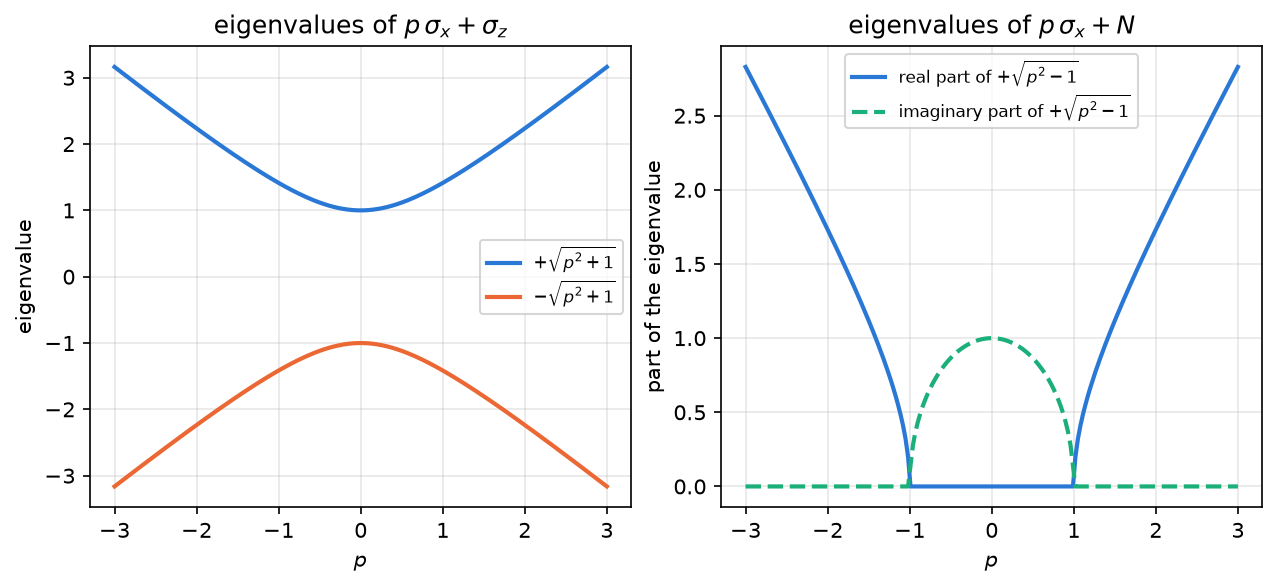

Figure 04b.1 saved as Revision/textbook/figures/04b_1_square_roots_2x2.png


In [4]:
p_values = np.linspace(-3.0, 3.0, 201)  # 201 equally spaced values of p
sx = np.array(sigma_x, dtype=float)  # the same matrices as numpy arrays
sz = np.array(sigma_z, dtype=float)
n_matrix = np.array(N, dtype=float)
euclid_eigen = np.array([np.sort(np.linalg.eigvals(pv * sx + sz).real)
                         for pv in p_values])  # q = 1
indef_eigen = np.array([np.linalg.eigvals(pv * sx + n_matrix) for pv in p_values])
root_euclid = np.sqrt(p_values**2 + 1.0)
root_indef = np.sqrt((p_values**2 - 1.0).astype(complex))  # complex square root
errors = [np.max(np.abs(euclid_eigen[:, 1] - root_euclid)),
          np.max(np.abs(np.sort(np.abs(indef_eigen), axis=1)[:, 1]
                        - np.abs(root_indef)))]
check(max(errors) < 1e-12, "numpy eigenvalues equal +-sqrt(p^2 + 1), +-sqrt(p^2 - 1)")

fig, (left, right) = plt.subplots(1, 2, figsize=(8.4, 3.8), layout="constrained")
left.plot(p_values, root_euclid, color="#2a78d6", linewidth=2,
          label="$+\\sqrt{p^2+1}$")
left.plot(p_values, -root_euclid, color="#eb6834", linewidth=2,
          label="$-\\sqrt{p^2+1}$")
left.set_title("eigenvalues of $p\\,\\sigma_x + \\sigma_z$")
left.set_xlabel("$p$")
left.set_ylabel("eigenvalue")
left.legend(fontsize=8)
right.plot(p_values, np.abs(root_indef.real), color="#2a78d6", linewidth=2,
           label="real part of $+\\sqrt{p^2-1}$")
right.plot(p_values, np.abs(root_indef.imag), color="#1baf7a", linewidth=2,
           linestyle="--", label="imaginary part of $+\\sqrt{p^2-1}$")
right.set_title("eigenvalues of $p\\,\\sigma_x + N$")
right.set_xlabel("$p$")
right.set_ylabel("part of the eigenvalue")
right.legend(fontsize=8)
save_figure(fig, "square_roots_2x2",
            "Eigenvalues of two $2 \\times 2$ square roots, for $q = 1$ and $p$ "
            "from $-3$ to $3$ (pure numbers). Left: $p\\sigma_x + \\sigma_z$ squares "
            "to $(p^2 + 1) I_2$, and its eigenvalues are always the two real "
            "numbers $\\pm\\sqrt{p^2 + 1}$. Right: $p\\sigma_x + N$ squares to "
            "$(p^2 - 1) I_2$; its eigenvalues $\\pm\\sqrt{p^2 - 1}$ are real for "
            "$|p| > 1$ (solid line, the real part of the positive one) and "
            "imaginary for $|p| < 1$ (dashed line, the imaginary part): a minus "
            "sign in the quadratic form makes the root imaginary when the minus "
            "term wins.")

## 7. The Pauli matrices: three directions

A third real $2 \times 2$ matrix that anticommutes with $\sigma_x$ and $\sigma_z$ and
squares to $+I_2$ does not exist, but a complex one does:
$\sigma_y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$. The three **Pauli
matrices** (Wolfgang Pauli, 1927) satisfy the Clifford relation with
$\eta = \mathrm{diag}(+1, +1, +1)$. The next cell computes the table of numbers
$c_{ab}$ with $\{\sigma_a, \sigma_b\} = c_{ab} I_2$, checks that it is $2\delta_{ab}$,
and checks the products $\sigma_x\sigma_y = i\sigma_z$ and
$\sigma_x\sigma_y\sigma_z = i I_2$ (by hand:
$\sigma_x\sigma_y = \begin{pmatrix} i & 0 \\ 0 & -i \end{pmatrix} = i\sigma_z$, then
$i\sigma_z\sigma_z = i I_2$). In sympy the imaginary unit is `sp.I`.

In [5]:
sigma_y = sp.Matrix([[0, -sp.I], [sp.I, 0]])
pauli = [sigma_x, sigma_y, sigma_z]


def table_of(matrices, size):
    """The numbers c_ab with {M_a, M_b} = c_ab I; None where it is not a multiple."""
    rows = []
    for ma in matrices:
        row = []
        for mb in matrices:
            m = (ma * mb + mb * ma).expand()
            row.append(m[0, 0] if m == m[0, 0] * sp.eye(size) else None)
        rows.append(row)
    return rows


pauli_table = table_of(pauli, 2)
say(f"Pauli table c_ab: {pauli_table}")
check(pauli_table == [[2, 0, 0], [0, 2, 0], [0, 0, 2]],
      "{sigma_a, sigma_b} = 2 delta_ab I2 for the three Pauli matrices")
check(sigma_x * sigma_y == sp.I * sigma_z and sigma_x * sigma_y * sigma_z == sp.I * I2,
      "sigma_x sigma_y = i sigma_z and sigma_x sigma_y sigma_z = i I2")

Pauli table c_ab: [[2, 0, 0], [0, 2, 0], [0, 0, 2]]
PASS {sigma_a, sigma_b} = 2 delta_ab I2 for the three Pauli matrices
PASS sigma_x sigma_y = i sigma_z and sigma_x sigma_y sigma_z = i I2


## 8. Dirac's matrices: time and three space directions

$2 \times 2$ matrices are too small for four anticommuting matrices. Dirac's choice,
in the particle physicists' convention $\eta = \mathrm{diag}(+1, -1, -1, -1)$ (time
first, sign $+1$), is built from $2 \times 2$ blocks:
$\gamma_D^0 = \begin{pmatrix} I_2 & 0 \\ 0 & -I_2 \end{pmatrix}$ and
$\gamma_D^j = \begin{pmatrix} 0 & \sigma_j \\ -\sigma_j & 0 \end{pmatrix}$ for
$j = x, y, z$. (The letter D keeps them apart from the author's gammas.) By the
block rule, $(\gamma_D^j)^2 = \mathrm{diag}(-\sigma_j^2, -\sigma_j^2) = -I_4$ and
$\gamma_D^0\gamma_D^j = -\gamma_D^j\gamma_D^0$. The next cell builds them with sympy's
`sp.Matrix(sp.BlockMatrix(...))` and checks the whole $4 \times 4$ table.

In [6]:
Z2 = sp.zeros(2, 2)
dirac = [sp.Matrix(sp.BlockMatrix([[I2, Z2], [Z2, -I2]]))]  # gamma_D^0
for s in pauli:  # gamma_D^x, gamma_D^y, gamma_D^z
    dirac.append(sp.Matrix(sp.BlockMatrix([[Z2, s], [-s, Z2]])))
dirac_table = table_of(dirac, 4)
say(f"Dirac table c_ab: {dirac_table}")
check(dirac_table == [[2, 0, 0, 0], [0, -2, 0, 0], [0, 0, -2, 0], [0, 0, 0, -2]],
      "{gamma_D^a, gamma_D^b} = 2 diag(+1, -1, -1, -1)_ab I4")

Dirac table c_ab: [[2, 0, 0, 0], [0, -2, 0, 0], [0, 0, -2, 0], [0, 0, 0, -2]]
PASS {gamma_D^a, gamma_D^b} = 2 diag(+1, -1, -1, -1)_ab I4


The next cell draws the two tables as heat maps, each number written into its
square.

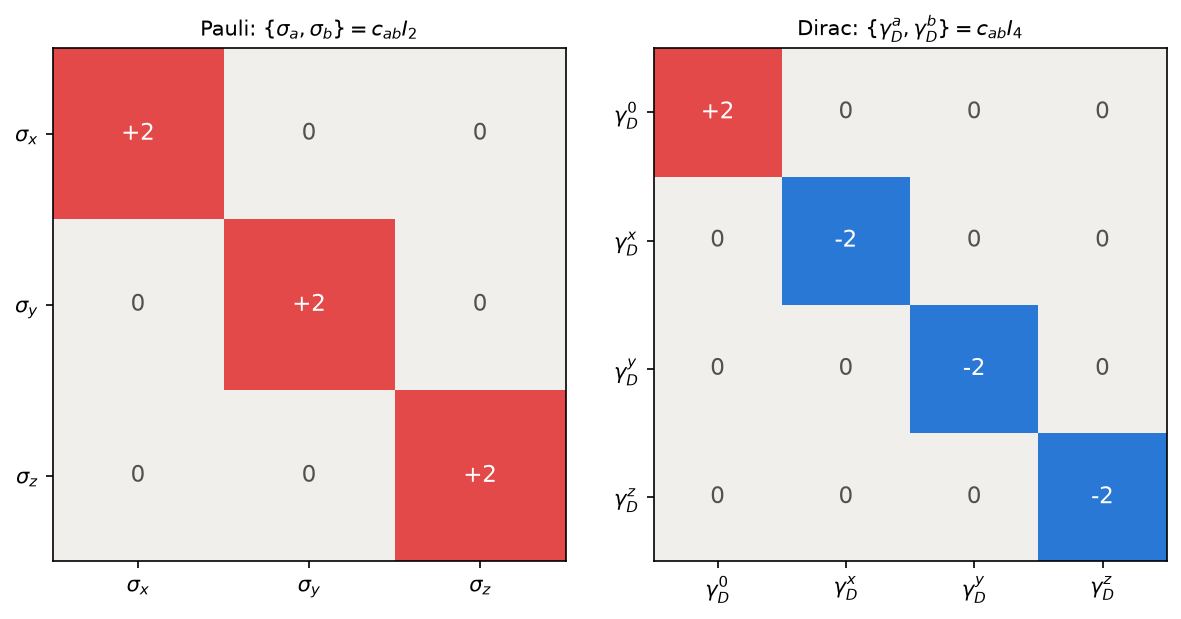

Figure 04b.2 saved as Revision/textbook/figures/04b_2_pauli_dirac_tables.png


In [7]:
from matplotlib.colors import BoundaryNorm, ListedColormap

TABLE_COLOURS = ListedColormap(["#2a78d6", "#f0efec", "#e34948"])  # -2, 0, +2
TABLE_NORM = BoundaryNorm([-3, -1, 1, 3], 3)


def draw_table(ax, table, labels, title):
    """Draw a table of the numbers c_ab as a heat map with the numbers written in."""
    values = np.array(table, dtype=float)
    ax.imshow(values, cmap=TABLE_COLOURS, norm=TABLE_NORM)
    for (a, b), value in np.ndenumerate(values):
        ax.text(b, a, f"{int(value):+d}" if value else "0", ha="center",
                va="center", color="white" if value else "#52514e", fontsize=11)
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_title(title, fontsize=10)
    ax.grid(False)


fig, (left, right) = plt.subplots(1, 2, figsize=(8.0, 4.0), layout="constrained")
draw_table(left, pauli_table, ["$\\sigma_x$", "$\\sigma_y$", "$\\sigma_z$"],
           "Pauli: $\\{\\sigma_a, \\sigma_b\\} = c_{ab} I_2$")
draw_table(right, dirac_table, ["$\\gamma_D^0$", "$\\gamma_D^x$", "$\\gamma_D^y$",
                                "$\\gamma_D^z$"],
           "Dirac: $\\{\\gamma_D^a, \\gamma_D^b\\} = c_{ab} I_4$")
save_figure(fig, "pauli_dirac_tables",
            "The Clifford relation of the Pauli matrices (left) and of Dirac's "
            "matrices (right): the number $c_{ab}$ in "
            "$\\{M_a, M_b\\} = c_{ab} I$ for every pair, row $a$ and column $b$ "
            "(red $+2$, blue $-2$, grey $0$). Off the diagonal every entry is $0$: "
            "different matrices anticommute. On the diagonal stand twice the signs "
            "of the directions: $+2$ for the three space directions of Pauli, and "
            "$+2$ for Dirac's time and $-2$ for his three space directions.")

**What Dirac's matrices do.** Dirac's equation is
$i(\gamma_D^0\partial_t + \gamma_D^x\partial_1 + \gamma_D^y\partial_2 +
\gamma_D^z\partial_3)\psi = m\psi$. For a plane wave
$\psi = u\,e^{-i(E t - k_1x_1 - k_2x_2 - k_3x_3)}$ the derivative $\partial_t$ gives the
factor $-iE$ and $\partial_j$ the factor $ik_j$; with the $i$ in front these become
$E$ and $-k_j$, so the plane wave solves the equation when
$(E\gamma_D^0 - k_1\gamma_D^x - k_2\gamma_D^y - k_3\gamma_D^z - m I_4)u = 0$. Call
$P = E\gamma_D^0 - k_1\gamma_D^x - k_2\gamma_D^y
- k_3\gamma_D^z$. By the general rule of the situation section, with the signs
$(+1, -1, -1, -1)$, $P^2 = (E^2 - k_1^2 - k_2^2 - k_3^2) I_4$. A nonzero $u$ with
$(P - m)u = 0$ satisfies $Pu = mu$, hence $P^2 u = m^2 u$, hence
$E^2 - k_1^2 - k_2^2 - k_3^2 = m^2$: the relativistic energy relation, the *mass
shell*. The next cell checks $P^2$ exactly with symbols, then takes $m = 3$ and
$k = (4, 0, 0)$, for which the mass shell is $E^2 = 9 + 16 = 25$, $E = \pm 5$, and
computes the smallest singular value of $P - m I_4$ for 801 energies from $-8$ to
$8$. It is zero exactly where a solution $u$ exists, and the check confirms that
this happens at $E = \pm 5$ and that there are two independent solutions there
(two singular values are zero).

In [8]:
E, k1, k2, k3 = sp.symbols("E k1 k2 k3", real=True)
P = E * dirac[0] - k1 * dirac[1] - k2 * dirac[2] - k3 * dirac[3]
check((P * P).expand() == (E**2 - k1**2 - k2**2 - k3**2) * sp.eye(4),
      "(E gamma_D^0 - k . gamma_D)^2 = (E^2 - k^2) I4 for all E and k")

dirac_numeric = [np.array(g, dtype=complex) for g in dirac]  # numpy copies


def smallest_singular_value(matrix):
    """The smallest length of matrix @ u over all columns u of length 1."""
    return np.linalg.svd(matrix, compute_uv=False).min()


mass, momentum = 3.0, (4.0, 0.0, 0.0)
energies = np.linspace(-8.0, 8.0, 801)  # steps of 0.02


def dirac_operator(energy):
    """P - m I4 for the energy energy and the fixed momentum and mass."""
    P_num = energy * dirac_numeric[0]
    for j in range(3):
        P_num = P_num - momentum[j] * dirac_numeric[j + 1]
    return P_num - mass * np.eye(4)


dirac_svals = np.array([smallest_singular_value(dirac_operator(e))
                        for e in energies])
# The energies where it vanishes, rounded to 6 decimals, as plain Python numbers:
zeros_at = [float(x) for x in np.round(energies[dirac_svals < 1e-9], 6)]
report("energies where a Dirac plane wave exists", zeros_at)
kernel = np.sum(np.linalg.svd(dirac_operator(5.0), compute_uv=False) < 1e-9)
report("independent solutions u at E = 5", int(kernel))
check(zeros_at == [-5.0, 5.0] and kernel == 2,
      "Dirac plane waves exist exactly at E = +-sqrt(m^2 + k^2) = +-5")

PASS (E gamma_D^0 - k . gamma_D)^2 = (E^2 - k^2) I4 for all E and k
RESULT energies where a Dirac plane wave exists = [-5.0, 5.0]
RESULT independent solutions u at E = 5 = 2
PASS Dirac plane waves exist exactly at E = +-sqrt(m^2 + k^2) = +-5


The next cell draws the smallest singular value of $P - mI_4$ against the energy.

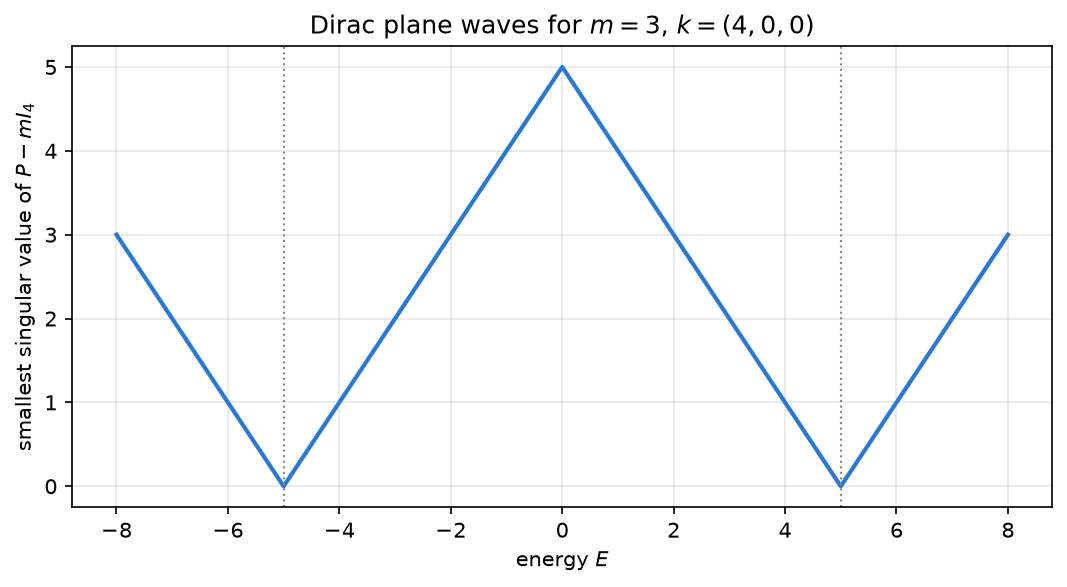

Figure 04b.3 saved as Revision/textbook/figures/04b_3_dirac_mass_shell.png


In [9]:
fig, ax = plt.subplots(figsize=(7.0, 3.8), layout="constrained")
ax.plot(energies, dirac_svals, color="#2a78d6", linewidth=2)
for e in (-5.0, 5.0):
    ax.axvline(e, color="#898781", linewidth=1, linestyle=":")
ax.set_xlabel("energy $E$")
ax.set_ylabel("smallest singular value of $P - m I_4$")
ax.set_title("Dirac plane waves for $m = 3$, $k = (4, 0, 0)$")
save_figure(fig, "dirac_mass_shell",
            "Where Dirac's equation has plane-wave solutions: the smallest "
            "singular value of $E\\gamma_D^0 - k\\cdot\\gamma_D - m I_4$ for mass "
            "$m = 3$, momentum $k = (4, 0, 0)$ and energies $E$ from $-8$ to $8$ "
            "(units with the speed of light 1; all quantities pure numbers). It is "
            "zero only at $E = \\pm 5$ (dotted lines), the two solutions of "
            "$E^2 = m^2 + k^2 = 25$: the first-order matrix equation contains the "
            "relativistic energy relation.")

## 9. The author's eight gammas: the square root in 4+4 dimensions

The next cell reads the author's gammas from the Revision record file
`Revision/algebra/gammas.json` (a list of eight matrices in the order
$x_1, \dots, x_8$, entries whole numbers) together with the signs $\eta$, and makes
a sympy copy. With eight symbols $p_1, \dots, p_8$ it forms
$\not p = \sum_a p_a\gamma^{(x_a)}$ (read "p slash") and checks exactly that
$\not p^{\,2} = (p_1^2 + p_2^2 + p_3^2 - p_4^2 - p_5^2 - p_6^2 - p_7^2 + p_8^2)
I_{16}$ for all values of the $p_a$. By the general rule of the situation section
this identity is the same statement as the Clifford relation of the eight
matrices.

In [10]:
record = json.loads(repository_file("Revision/algebra/gammas.json")
                    .read_text(encoding="utf-8"))
eta = record["eta"]  # [1, 1, 1, -1, -1, -1, -1, 1] in the order x1..x8
for matrix in record["gamma"]:  # the entries must be whole numbers
    if not all(isinstance(x, int) for row in matrix for x in row):
        raise ValueError("a gamma matrix of gammas.json has an entry that is not "
                         "a whole number")
gamma = [np.array(matrix, dtype=np.int64) for matrix in record["gamma"]]
sympy_gamma = [sp.Matrix(matrix) for matrix in record["gamma"]]
say("coordinates " + ", ".join(record["coordinates"]) + f"; eta = {eta}")

p_symbols = sp.symbols("p1:9", real=True)  # p1, p2, ..., p8
p_slash = sp.zeros(16, 16)
for a in range(8):
    p_slash += p_symbols[a] * sympy_gamma[a]
quadratic_form = sum(eta[a] * p_symbols[a] ** 2 for a in range(8))
say(f"quadratic form: {quadratic_form}")
check((p_slash * p_slash).expand() == quadratic_form * sp.eye(16),
      "(sum_a p_a gamma^(xa))^2 = eta(p, p) I16 for all p (exact)")

coordinates x1, x2, x3, x4, x5, x6, x7, x8; eta = [1, 1, 1, -1, -1, -1, -1, 1]
quadratic form: p1**2 + p2**2 + p3**2 - p4**2 - p5**2 - p6**2 - p7**2 + p8**2
PASS (sum_a p_a gamma^(xa))^2 = eta(p, p) I16 for all p (exact)


The same identity with numbers: the next cell draws 300 random vectors $p$ (each
component from a normal distribution, seed 12345, so every run uses the same
numbers), computes $\not p^{\,2}$ with floating-point numbers, and compares it with
$\eta(p, p) I_{16}$, where $\eta(p,p) = \sum_a \eta^{aa} p_a^2$. The check allows a
rounding error of $10^{-12}$. The figure shows the diagonal entry
$(\not p^{\,2})_{00}$ against $\eta(p, p)$ (the points lie on the line of slope 1)
and the largest rounding error of each vector on a logarithmic scale.

RESULT largest rounding error over 300 random vectors is at most = 1e-14
PASS (p slash)^2 = eta(p, p) I16 for 300 random vectors p


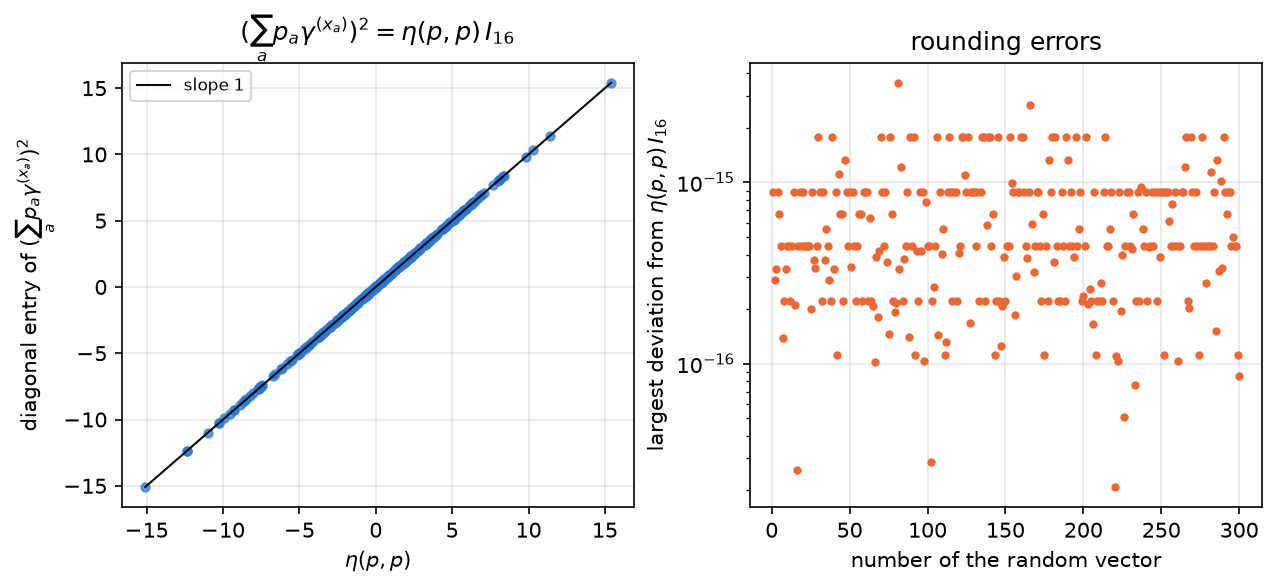

Figure 04b.4 saved as Revision/textbook/figures/04b_4_square_root_8d.png


In [11]:
generator = np.random.default_rng(12345)  # the seed makes the numbers repeatable
vectors = generator.normal(size=(300, 8))  # 300 vectors p with 8 components
forms, diagonal, worst = [], [], []
for vector in vectors:
    slash = sum(vector[a] * gamma[a] for a in range(8))  # p slash, a 16 x 16 array
    square = slash @ slash
    form = sum(eta[a] * vector[a] ** 2 for a in range(8))  # eta(p, p)
    forms.append(form)
    diagonal.append(square[0, 0])
    worst.append(np.max(np.abs(square - form * np.eye(16))))
# The exact size of the rounding errors depends on the computer; it is printed as
# a power of ten that it does not exceed.
bound = 10.0 ** np.ceil(np.log10(max(worst)))
report("largest rounding error over 300 random vectors is at most", f"{bound:.0e}")
check(max(worst) < 1e-12, "(p slash)^2 = eta(p, p) I16 for 300 random vectors p")

fig, (left, right) = plt.subplots(1, 2, figsize=(8.4, 3.8), layout="constrained")
left.plot(forms, diagonal, "o", markersize=4, color="#2a78d6", alpha=0.7)
line = np.array([min(forms), max(forms)])
left.plot(line, line, color="#0b0b0b", linewidth=1, label="slope 1")
left.set_xlabel("$\\eta(p, p)$")
left.set_ylabel("diagonal entry of $(\\sum_a p_a\\gamma^{(x_a)})^2$")
left.set_title("$(\\sum_a p_a\\gamma^{(x_a)})^2 = \\eta(p,p)\\, I_{16}$")
left.legend(fontsize=8)
right.semilogy(range(1, 301), np.maximum(worst, 1e-18), "o", markersize=3,
               color="#eb6834")
right.set_xlabel("number of the random vector")
right.set_ylabel("largest deviation from $\\eta(p,p)\\, I_{16}$")
right.set_title("rounding errors")
save_figure(fig, "square_root_8d",
            "The author's gammas take the square root of the 4+4 quadratic form, "
            "tested with 300 random vectors $p$ (pure numbers). Left: the diagonal "
            "entry of the matrix $(\\sum_a p_a\\gamma^{(x_a)})^2$ against "
            "$\\eta(p,p) = p_1^2 + p_2^2 + p_3^2 - p_4^2 - p_5^2 - p_6^2 - p_7^2 + "
            "p_8^2$; all points lie on the line of slope 1, for positive and "
            "negative $\\eta(p,p)$. Right: for each vector the largest deviation of "
            "an entry of this matrix from $\\eta(p,p) I_{16}$, on a logarithmic "
            "scale; it is below $10^{-14}$, the size of floating-point rounding (the "
            "exact identity is proved with symbols in the notebook).")

## 10. Plane waves in flat 4+4 space

In flat 4+4 space the field equation without self-interaction is
$\sum_a \gamma^{(x_a)}\partial_a\Psi = m\Psi$ ($\partial_a$ is the derivative with
respect to $x_a$). Take a plane wave
$\Psi = u\,e^{i(k_1x_1 + k_2x_2 + k_3x_3 + k_5x_5 + k_6x_6 + k_7x_7 + k_8x_8 - Ex_4)}$
with a constant column $u$. Line by line:

1. $\partial_a\Psi = ik_a\Psi$ for $a \neq 4$ and $\partial_4\Psi = -iE\Psi$ (the
   derivative of $e^{cx}$ is $ce^{cx}$).
2. Inserting and dividing by the exponential (never zero):
   $-iE\gamma^{(x_4)}u + i\sum_{a\neq4}k_a\gamma^{(x_a)}u = mu$.
3. Multiplying from the left by $\gamma^{(x_4)}$ and using
   $(\gamma^{(x_4)})^2 = -I_{16}$ ($x_4$ is time-like):
   $iEu + i\sum_{a\neq4}k_a\gamma^{(x_4)}\gamma^{(x_a)}u = m\gamma^{(x_4)}u$.
4. Multiplying by $-i$ (and $-i \cdot i = 1$):
   $Eu + \sum_{a\neq4}k_a\gamma^{(x_4)}\gamma^{(x_a)}u = -im\gamma^{(x_4)}u$.
5. Moving the sum to the right-hand side:
   $Eu = hu$ with $h = -im\gamma^{(x_4)} - \sum_{a\neq4}k_a\gamma^{(x_4)}\gamma^{(x_a)}$.

So $E$ is an eigenvalue of the $16 \times 16$ matrix $h$. Write $h = m\beta +
\sum_{a\neq4}k_a\alpha_a$ with $\beta = -i\gamma^{(x_4)}$ and
$\alpha_a = -\gamma^{(x_4)}\gamma^{(x_a)}$. Then, from the Clifford relation
(write $g_4$ for $\gamma^{(x_4)}$ and $g_a$ for $\gamma^{(x_a)}$; $g_4^2 = -1$,
$g_a^2 = \eta^{aa}$, and different gammas anticommute):

- $\beta^2 = (-i)^2 g_4^2 = (-1)(-1) = 1$;
- $\alpha_a^2 = g_4 g_a g_4 g_a = -g_4 g_4 g_a g_a = -(-1)\eta^{aa} = \eta^{aa}$ (one
  exchange of $g_a$ and $g_4$ gives the minus sign);
- $\beta\alpha_a = i g_4 g_4 g_a = -i g_a$ and
  $\alpha_a\beta = i g_4 g_a g_4 = -i g_4 g_4 g_a = i g_a$: they anticommute;
- for $a \neq b$: $\alpha_a\alpha_b = g_4 g_a g_4 g_b = -g_4 g_4 g_a g_b = g_a g_b$,
  and $\alpha_b\alpha_a = g_b g_a = -g_a g_b$: they anticommute.

So $\beta$ and the $\alpha_a$ obey a Clifford relation, and by the general rule of
the situation section $h^2 = (m^2 + \sum_{a\neq4}\eta^{aa}k_a^2) I_{16}$, that is

$$h^2 = (m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2)\, I_{16},
\qquad E^2 = m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2 .$$

The next cell checks the formula for $h^2$ exactly with symbols. The Revision record
verified the same formula (`Revision/theory/reports/python-field-theory.json`, check
`mode_hamiltonian_B_selfadjoint_dispersion`); that check also verifies a statement
about a matrix $B$ that is not needed here.

In [12]:
THEORY = "Revision/theory/reports/python-field-theory.json"
theory = json.loads(repository_file(THEORY).read_text(encoding="utf-8"))
theory_checks = {entry["name"]: entry for entry in theory["checks"]}


def recorded_pass(name):
    """True when the theory report holds the check name with the verdict pass."""
    return theory_checks.get(name, {}).get("verdict", "").upper() == "PASS"


m, k = sp.symbols("m", real=True), sp.symbols("k1:9", real=True)  # k[0] is k1
g4 = sympy_gamma[3]  # gamma^(x4)
h = -sp.I * m * g4
for a in range(8):
    if a != 3:  # every direction except the time x4
        h -= k[a] * g4 * sympy_gamma[a]
dispersion = m**2 + k[0]**2 + k[1]**2 + k[2]**2 + k[7]**2 \
    - k[4]**2 - k[5]**2 - k[6]**2
check((h * h).expand() == dispersion * sp.eye(16)
      and recorded_pass("mode_hamiltonian_B_selfadjoint_dispersion"),
      "h^2 = (m^2 + k1^2 + k2^2 + k3^2 + k8^2 - k5^2 - k6^2 - k7^2) I16")
print(f"     reproduces {THEORY}")
print("         check mode_hamiltonian_B_selfadjoint_dispersion (formula for h^2)")

PASS h^2 = (m^2 + k1^2 + k2^2 + k3^2 + k8^2 - k5^2 - k6^2 - k7^2) I16
     reproduces Revision/theory/reports/python-field-theory.json
         check mode_hamiltonian_B_selfadjoint_dispersion (formula for h^2)


**The exact example of the Revision record.** Without momentum along the extra
times ($k_5 = k_6 = k_7 = 0$; the Revision record calls this the *good sector*)
$h$ is Hermitian and its eigenvalues are real. The reason: the author's gammas are
real with $(g_a)^T = \eta^{aa} g_a$ (symmetric for space-like, antisymmetric for
time-like directions). So $\beta^\dagger = i g_4^T = -i g_4 = \beta$, and
$\alpha_a$ is real with $\alpha_a^T = -g_a^T g_4^T = \eta^{aa} g_a g_4
= -\eta^{aa} g_4 g_a = \eta^{aa}\alpha_a$: Hermitian for the space-like
$a = x_1, x_2, x_3, x_8$ (and anti-Hermitian for the extra times, which is why
they are left out here). For $m = 2$ and $(k_1, k_2, k_3, k_8) = (1, 2, 0, 4)$:
$E^2 = 4 + 1 + 4 + 0 + 16 = 25$, $E = \pm 5$. Because $h$ has trace 0 (every gamma
product in it has trace 0) and $h^2 = 25 I_{16}$, the eigenvalue $+5$ occurs 8 times
and $-5$ occurs 8 times. The next cell computes the eigenvalues numerically, checks
them, and reproduces the record's statement. It also computes, for 801 energies from
$-8$ to $8$, the smallest singular value of $EI_{16} - h$; for a Hermitian $h$ it is
the distance from $E$ to the nearest eigenvalue.

In [13]:
gamma_complex = [g.astype(complex) for g in gamma]


def h_matrix(mass_value, momenta):
    """The numeric h for the mass and the eight momenta (momenta[3] is not used)."""
    result = -1j * mass_value * gamma_complex[3]
    for a in range(8):
        if a != 3:
            result = result - momenta[a] * gamma_complex[3] @ gamma_complex[a]
    return result


example = h_matrix(2.0, [1.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0])
hermitian = np.array_equal(example, example.conj().T)  # h^dagger = h, exactly
eigenvalues = np.linalg.eigvalsh(example)  # real eigenvalues, increasing order
rounded = [float(x) for x in np.round(eigenvalues, 9)]  # 9 decimals
multiplicities = {value: rounded.count(value) for value in sorted(set(rounded))}
report("eigenvalues of h (m = 2, k = (1, 2, 0, k8 = 4)) with multiplicities",
       multiplicities)
eight_each = np.allclose(eigenvalues[:8], -5.0, atol=1e-12) and \
    np.allclose(eigenvalues[8:], 5.0, atol=1e-12)
check(hermitian and eight_each
      and recorded_pass("good_sector_spectrum_and_B_sectors"),
      "good sector: h is Hermitian with energies +5 and -5, eight each")
print(f"     reproduces {THEORY}")
print("         check good_sector_spectrum_and_B_sectors (its exact example)")

energies_4p4 = np.linspace(-8.0, 8.0, 801)
svals_4p4 = np.array([smallest_singular_value(e * np.eye(16) - example)
                      for e in energies_4p4])
distance = np.minimum(np.abs(energies_4p4 - 5.0), np.abs(energies_4p4 + 5.0))
check(np.max(np.abs(svals_4p4 - distance)) < 1e-9,
      "smallest singular value of E - h = distance from E to +-5")

RESULT eigenvalues of h (m = 2, k = (1, 2, 0, k8 = 4)) with multiplicities = {-5.0: 8,
    5.0: 8}
PASS good sector: h is Hermitian with energies +5 and -5, eight each
     reproduces Revision/theory/reports/python-field-theory.json
         check good_sector_spectrum_and_B_sectors (its exact example)
PASS smallest singular value of E - h = distance from E to +-5


The next cell draws the smallest singular value of $EI_{16} - h$ against $E$.

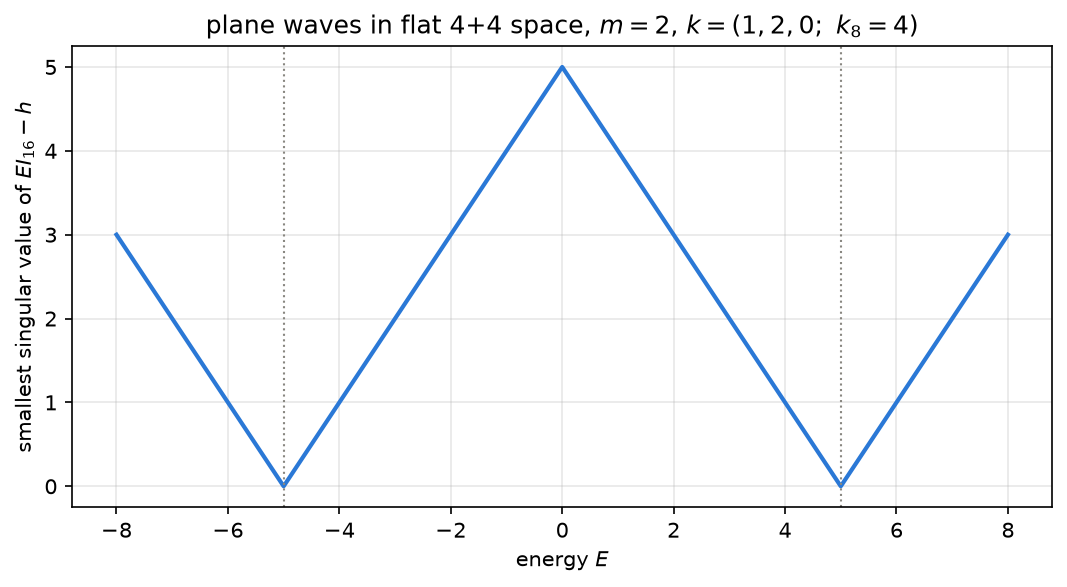

Figure 04b.5 saved as Revision/textbook/figures/04b_5_mass_shell_4p4.png


In [14]:
fig, ax = plt.subplots(figsize=(7.0, 3.8), layout="constrained")
ax.plot(energies_4p4, svals_4p4, color="#2a78d6", linewidth=2)
for e in (-5.0, 5.0):
    ax.axvline(e, color="#898781", linewidth=1, linestyle=":")
ax.set_xlabel("energy $E$")
ax.set_ylabel("smallest singular value of $E I_{16} - h$")
ax.set_title("plane waves in flat 4+4 space, $m = 2$, $k = (1, 2, 0;\\ k_8 = 4)$")
save_figure(fig, "mass_shell_4p4",
            "Plane waves of the author's first-order equation in flat 4+4 space "
            "without extra-time momentum: the smallest singular value of "
            "$E I_{16} - h$ for $m = 2$, $(k_1, k_2, k_3, k_8) = (1, 2, 0, 4)$ and "
            "energies $E$ from $-8$ to $8$ (pure numbers). It is the distance from "
            "$E$ to the nearest of the eigenvalues $\\pm 5$ (dotted lines) and "
            "vanishes only there, where $E^2 = m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 "
            "= 25$; each of the two energies belongs to eight independent "
            "solutions. The curve has the same shape as for Dirac's matrices: the "
            "same algebra in more directions.")

## 11. Momentum along an extra time

The extra times enter $E^2$ with a minus sign: $E^2 = 25 - k_5^2$ for the example
above with a momentum $k_5$ along the extra time $x_5$. For $k_5 < 5$ the energies
$\pm\sqrt{25 - k_5^2}$ are real; for $k_5 > 5$ they are imaginary, $E = \pm i
\sqrt{k_5^2 - 25}$, and the factor $e^{-iEx_4}$ of the plane wave then grows or
shrinks exponentially in the time $x_4$ instead of oscillating. This is the same
effect as in the right panel of the first figure, now in the author's 4+4
space-time; it is a fact about the flat equation, and the Revision record studies
its consequences separately. The next cell computes the 16 eigenvalues of $h$
numerically for 160 values of $k_5$ from 0.025 to 7.975 (the point $k_5 = 5$, where
both energies are 0, is left out), checks that 8 of them are
$+\sqrt{25 - k_5^2}$ and 8 are $-\sqrt{25 - k_5^2}$ (complex square root) to
$10^{-10}$, and draws their real and imaginary parts.

RESULT largest deviation from +-sqrt(25 - k5^2) is at most = 1e-13
PASS with momentum k5: eight energies +sqrt(25 - k5^2), eight -sqrt(25 - k5^2)


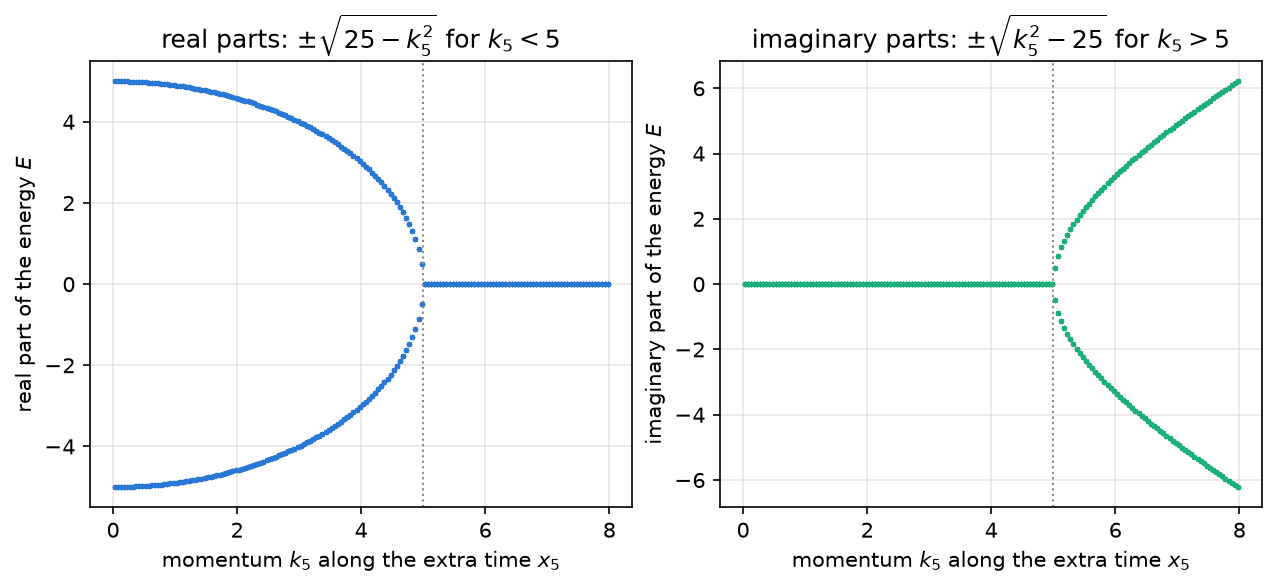

Figure 04b.6 saved as Revision/textbook/figures/04b_6_extra_time_momentum.png


In [15]:
k5_values = np.linspace(0.025, 7.975, 160)  # steps of 0.05, avoiding k5 = 5
real_parts, imaginary_parts, deviations, counts_ok = [], [], [], True
for k5 in k5_values:
    values = np.linalg.eigvals(h_matrix(2.0, [1.0, 2.0, 0.0, 0.0, k5, 0.0, 0.0, 4.0]))
    root = np.sqrt(complex(25.0 - k5**2))  # +sqrt(25 - k5^2), complex if needed
    to_plus, to_minus = np.abs(values - root), np.abs(values + root)
    deviations.append(np.max(np.minimum(to_plus, to_minus)))
    counts_ok &= bool(np.sum(to_plus < to_minus) == 8)  # eight near +root
    real_parts.append(np.sort(values.real))
    imaginary_parts.append(np.sort(values.imag))
bound = 10.0 ** np.ceil(np.log10(max(deviations)))  # a power of ten, as above
report("largest deviation from +-sqrt(25 - k5^2) is at most", f"{bound:.0e}")
check(max(deviations) < 1e-10 and counts_ok,
      "with momentum k5: eight energies +sqrt(25 - k5^2), eight -sqrt(25 - k5^2)")

real_parts, imaginary_parts = np.array(real_parts), np.array(imaginary_parts)
fig, (left, right) = plt.subplots(1, 2, figsize=(8.4, 3.8), layout="constrained")
for column in range(16):  # the 16 eigenvalues; they lie on two curves
    left.plot(k5_values, real_parts[:, column], ".", markersize=3, color="#2a78d6")
    right.plot(k5_values, imaginary_parts[:, column], ".", markersize=3,
               color="#1baf7a")
for ax, part in ((left, "real"), (right, "imaginary")):
    ax.axvline(5.0, color="#898781", linewidth=1, linestyle=":")
    ax.set_xlabel("momentum $k_5$ along the extra time $x_5$")
    ax.set_ylabel(f"{part} part of the energy $E$")
left.set_title("real parts: $\\pm\\sqrt{25 - k_5^2}$ for $k_5 < 5$")
right.set_title("imaginary parts: $\\pm\\sqrt{k_5^2 - 25}$ for $k_5 > 5$")
save_figure(fig, "extra_time_momentum",
            "The 16 energies $E$ of the plane waves of the example ($m = 2$, "
            "$(k_1, k_2, k_3, k_8) = (1, 2, 0, 4)$) when a momentum $k_5$ along the "
            "extra time $x_5$ is added, for $k_5$ from 0 to 8 (pure numbers, flat "
            "4+4 space). Left: real parts; right: imaginary parts. The energies "
            "obey $E^2 = 25 - k_5^2$: eight equal $+\\sqrt{25 - k_5^2}$ and eight "
            "$-\\sqrt{25 - k_5^2}$; they are real for $k_5 < 5$ and imaginary for "
            "$k_5 > 5$ (dotted line at $k_5 = 5$), because the extra times enter "
            "the quadratic form with a minus sign.")

## 12. The last check

The last cell checks that the six figure files exist in the folder
`Revision/textbook/figures` and prints the number of checks that passed.

In [16]:
names = ["04b_1_square_roots_2x2.png", "04b_2_pauli_dirac_tables.png",
         "04b_3_dirac_mass_shell.png", "04b_4_square_root_8d.png",
         "04b_5_mass_shell_4p4.png", "04b_6_extra_time_momentum.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in names),
      "all six figure files exist")
all_checks_passed()

PASS all six figure files exist
ALL 16 CHECKS PASSED (notebook 04b)


## 13. What this notebook showed

- PROVED (exact, sympy): two numbers cannot take the square root of $p^2 + q^2$;
  anticommuting matrices can. $(p\sigma_x + q\sigma_z)^2 = (p^2 + q^2)I_2$ and
  $(p\sigma_x + qN)^2 = (p^2 - q^2)I_2$ with real $2 \times 2$ matrices; the Pauli
  matrices satisfy the Clifford relation for three space directions and Dirac's
  matrices for $\mathrm{diag}(+1, -1, -1, -1)$; Dirac's first-order equation
  contains $E^2 = m^2 + k^2$.
- PROVED (exact, sympy, with the gammas of the Revision record file
  `Revision/algebra/gammas.json`): $(\sum_a p_a\gamma^{(x_a)})^2 =
  (p_1^2 + p_2^2 + p_3^2 - p_4^2 - p_5^2 - p_6^2 - p_7^2 + p_8^2)I_{16}$ for all
  $p$: the author's gammas take the square root of the quadratic form of his
  space-time.
- PROVED (exact): plane waves of $\sum_a\gamma^{(x_a)}\partial_a\Psi = m\Psi$ in flat
  4+4 space obey $Eu = hu$ with $h^2 = (m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2
  - k_6^2 - k_7^2) I_{16}$; this reproduces the Revision record
  (`Revision/theory/reports/python-field-theory.json`, check
  `mode_hamiltonian_B_selfadjoint_dispersion`). COMPUTED (floating point; every
  deviation from the exact values is below $10^{-9}$): its exact example
  ($m = 2$, $k = (1, 2, 0, k_8 = 4)$) has the
  energies $+5$ and $-5$, eight each (check `good_sector_spectrum_and_B_sectors`),
  and a momentum along an extra time makes the energies imaginary when
  $k_5^2 > m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2$.
- ASSUMED: flat 4+4 space (constant metric $\eta$). The author's space-time is
  curved, 3-space inflates and the extra times deflate; these effects are not part
  of this notebook.